# Ableton Project Notebook
###### Updated 11/2024

#### Notebook Runtime
**Local**
* should work with same python3 environment as parse_projects.py

**Colab**
* run `./ableton_projects/start_notebook.sh` to start
server on `8888`
* see `start_notebook.sh` for installing python2 kernel and packages
* see https://research.google.com/colaboratory/local-runtimes.html


### Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import parse_projects as parser
from typing import List, Dict, Any
from IPython.display import display

print(f"Python Version:\n  {parser.PYTHON_VERSION}")


Python Version:
  3.13.0 (main, Oct  7 2024, 05:02:14) [Clang 16.0.0 (clang-1600.0.26.4)]


### Load Parsed Projects

In [2]:
#@title Get info for all Projects and cache

# Load projects using default args should work if notebook is in project dir.
load_most_recent_cached = False #@param {type:"boolean"}
project_dir = "./" #@param {type:"string"}
# Overwrite parser defaults
# SKIP_FOLDERS = [ 'Backup', 'old', 'Samples', 'Ableton Project Info', '.git'] #@param {type:"raw"}
# CACHE_DIR = "./logs/" #@param {type:"string"}


# Load from recent cache (fast)
if load_most_recent_cached: 
  project_info = parser.load_info(prefix=parser.CACHE_INFO_FILE, load_most_recent=True)
  project_counters = parser.load_dict_from_json(parser.COUNTER_JSON)
  project_df = parser.load_project_df_from_tsv(parser.PROJECT_TSV)

# Parse project .als files
else:
  project_info, project_counters, project_df = parser.run_parser(project_dir)


Project path: ./
Found Dirs: ['.DS_Store', '.git', '.gitignore', '.stfolder', '.stignore', '.stversions', 'Bongo Cat.webloc', '__Demo_tapes', '___Dimensions_', '____darkwave', '____guitarbeet', '____lightwave', '__acoustic tracks', '__dj mixes_', '__psychy rock  tracks', '__pycache__', '_beat incubator', '_casio cheese', '_chillwave 2011', '_electronic dance house', '_electronic dark haaus', '_electronic nova trans hous', '_lekato demos a12', '_remix edits cuts', '_witch house', 'ableton_projects.ipynb', 'logs', 'music_production - Shortcut.lnk', 'parse_projects.log', 'parse_projects.ps1', 'parse_projects.py', 'projects.tsv', 'start_notebook.ps1', 'start_notebook.sh', 'z__templates']
Skipping Dirs containing: ['.git', '.ipynb_checkpoints', '.stfolder', '.stversions', 'Ableton Project Info', 'Backup', 'Samples', 'old', 'z__templates']
Loading projects in ./.
 READING: synth gorve
 READING: deep house dancuy
 READING: dream beatjar
 READING: jarrey groove loops
 READING: groovr
 READING:

# Analysis

### TODO
  * See code below for start on AUs
* archive other copies to Backup folder, ideally one copy per project (or more for variations track vs dj)

In [3]:
n_recent = 5
print(f"{n_recent} most recently modified projects")
project_df.sort_values('modified').tail(n_recent)

5 most recently modified projects


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,
room floor dual acoustics am-g-bm 3.5,./__acoustic tracks/_acoustic jams sorted/3tr+...,11.0_11300,0.03,2024-12-02 22:43:48,2024-12-02 22:43:48,5,11,2024,2024,"AudioTrack, MasterTrack",StereoGain,NaN,NaN
kyle Jake funk [house][loops],./_electronic dance house/funk daft house kyle...,10.0_377,0.18,2024-12-02 22:45:45,2024-12-02 22:45:34,11,10,2024,2024,"AudioTrack, MidiTrack, MasterTrack","PluginDevice, AutoFilter, MidiArpeggiator, Ins...","LuSH-101, Drumazon",NaN
loose acousitc distorted vox loop jam,./____guitarbeet/60/loose acousitc distorted v...,11.0_11300,0.20,2024-12-02 23:59:50,2024-12-02 23:59:50,7,11,2024,2024,"AudioTrack, MidiTrack, MasterTrack","StereoGain, PluginDevice, Eq8, Gate, AudioEffe...","Reaktor 6 FX, Guitar Rig 5, Maschine 2, iZotop...",NaN
jarryork 23,./___Dimensions_/jarryork mac Project/jarryork...,11.0_11300,0.09,2024-12-03 00:05:14,2024-12-03 00:05:14,5,11,2024,2024,"AudioTrack, ReturnTrack, MasterTrack","StereoGain, Flanger, Eq8, PluginDevice, AutoPa...","Toraverb, iZotope Ozone 5",GS-201
jarryork,./___Dimensions_/jarryork mac Project/jarryork...,11.0_11300,0.09,2024-12-03 00:10:07,2024-12-03 00:10:07,6,11,2024,2024,"AudioTrack, MidiTrack, ReturnTrack, MasterTrack","StereoGain, Flanger, Eq8, PluginDevice, AutoPa...","Toraverb, iZotope Ozone 5",GS-201


Counter: ableton_version has 3 entries


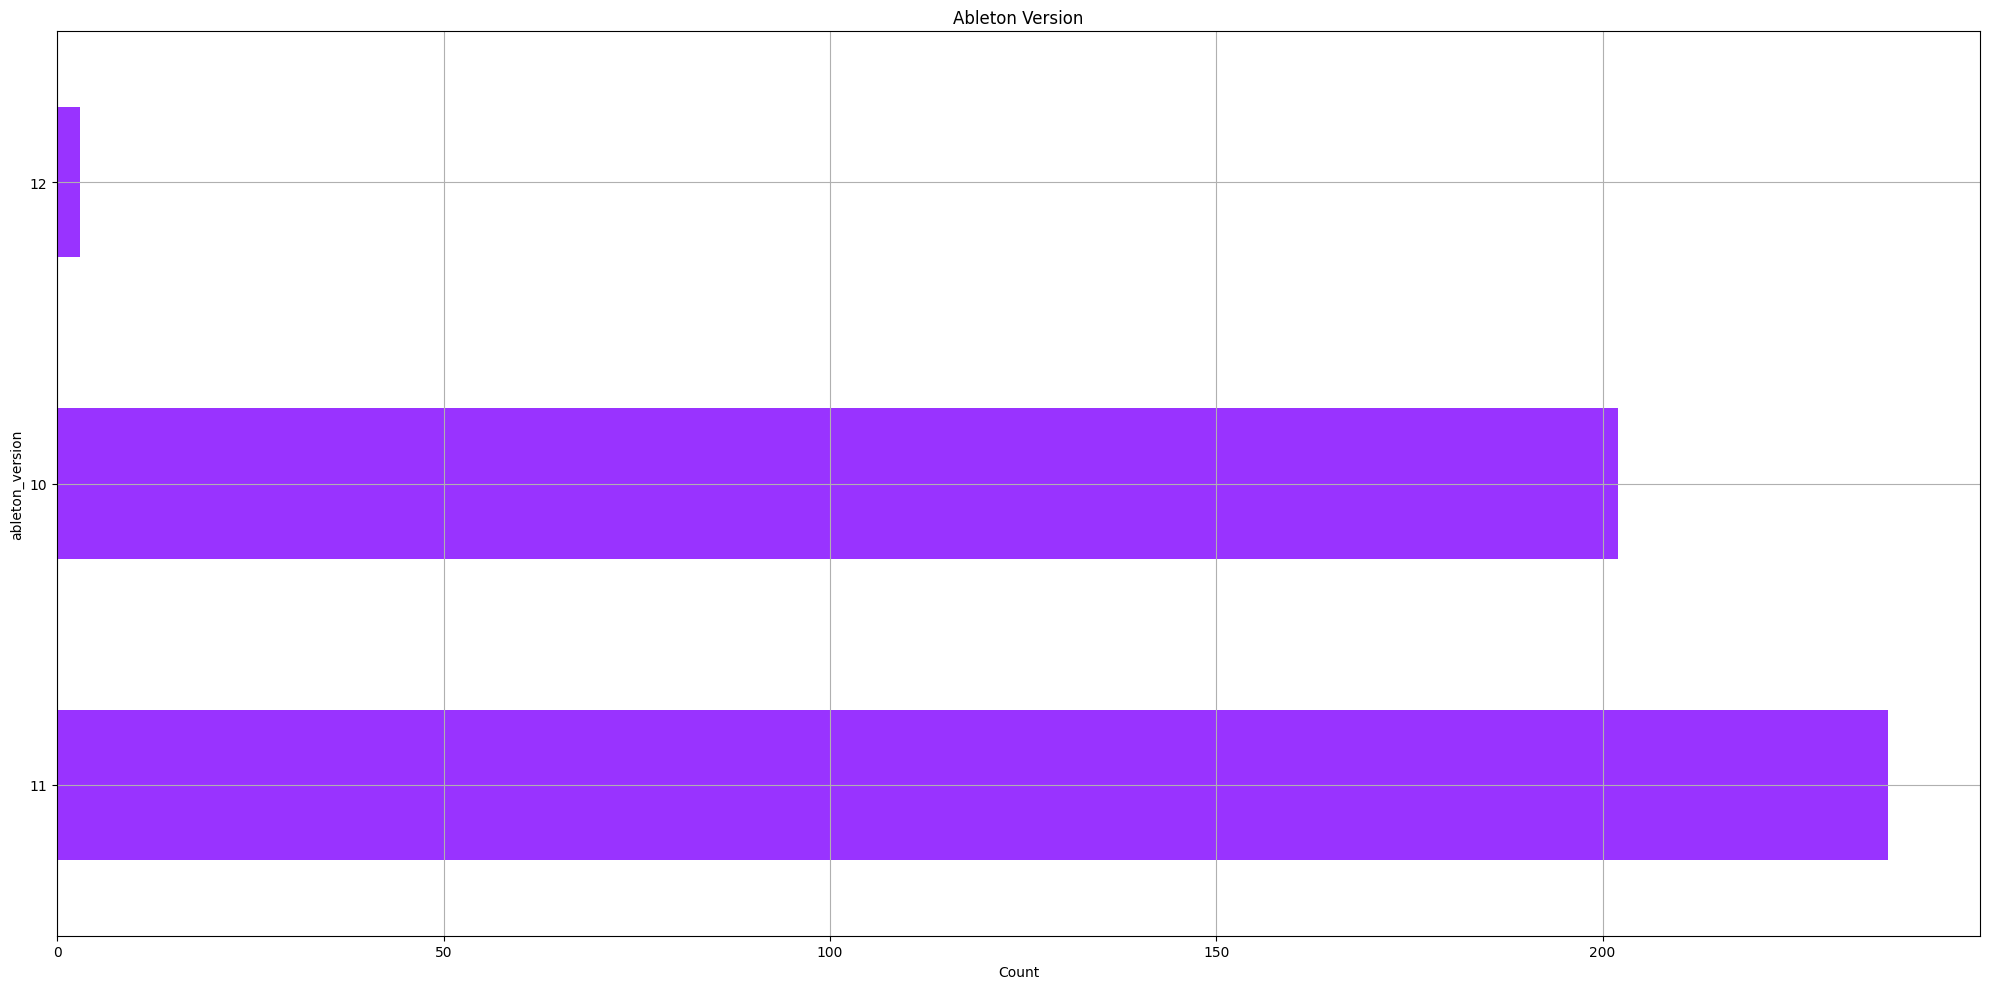

Counter: creation_year has 2 entries


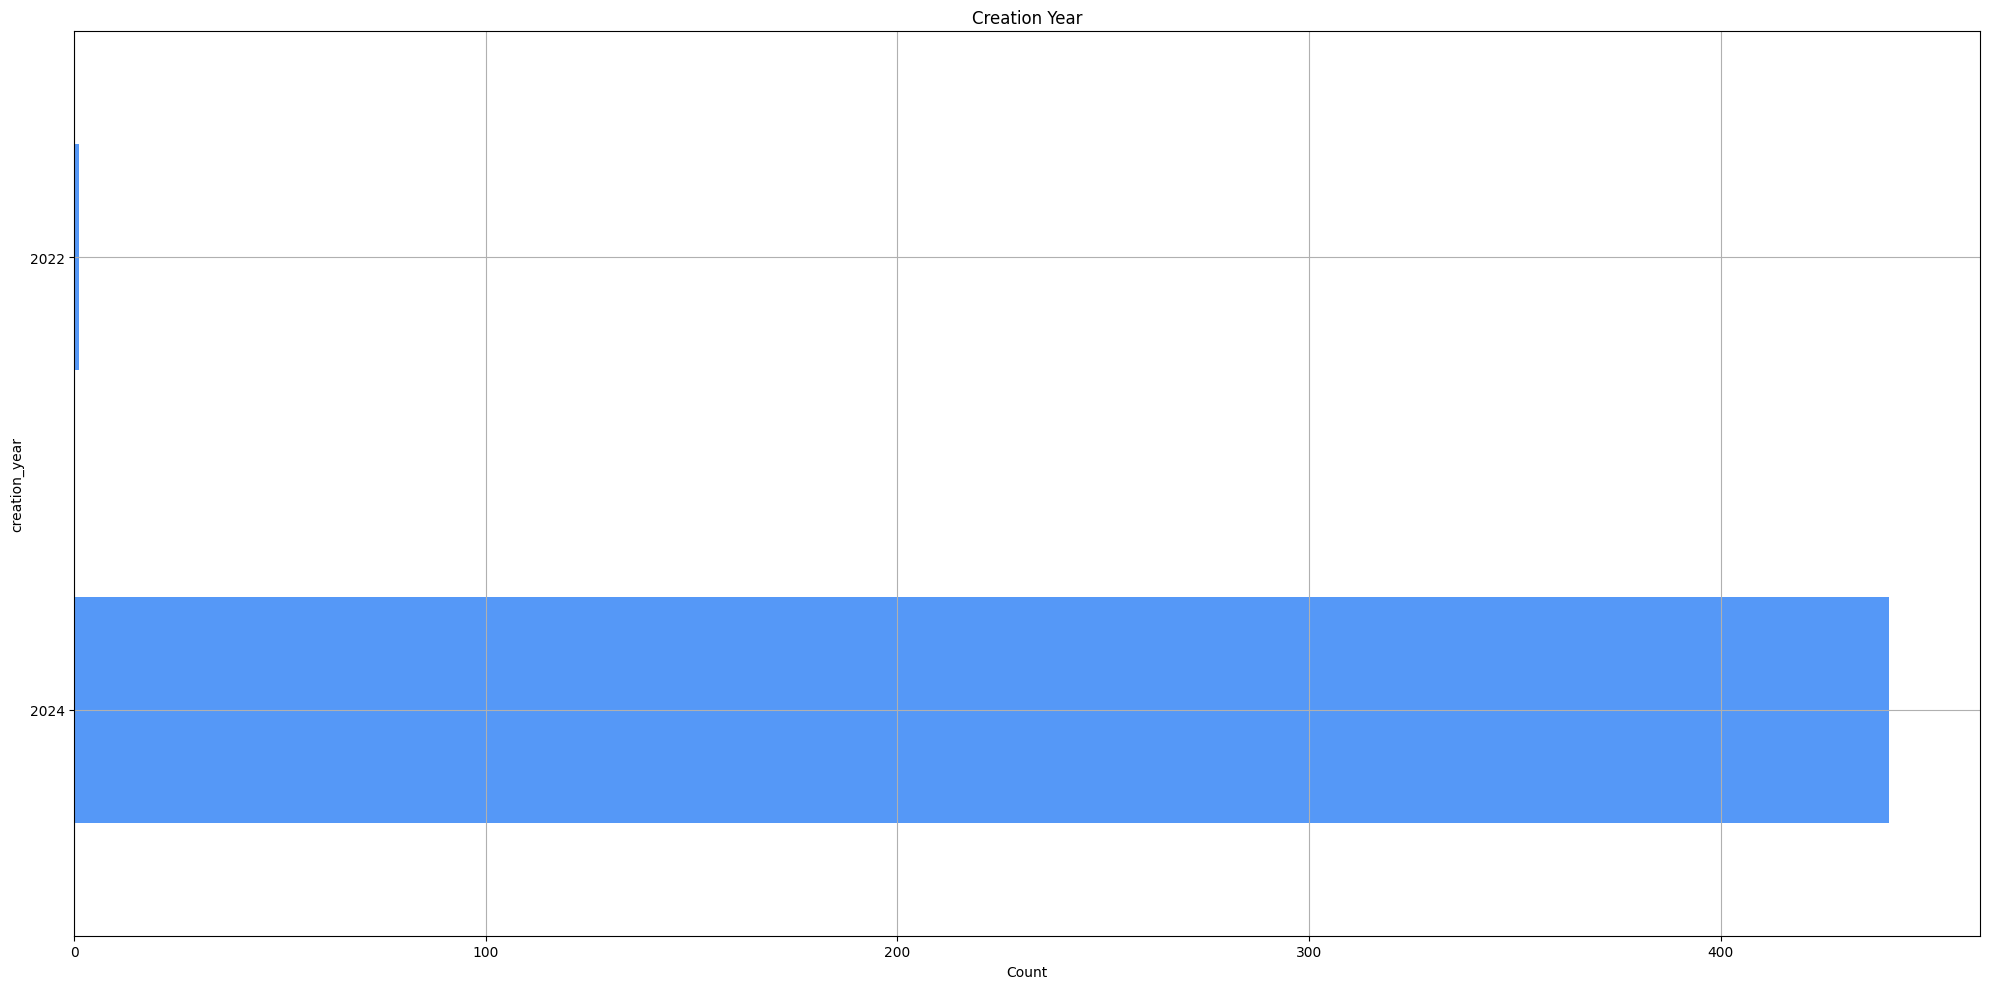

Counter: last_modified_year has 7 entries


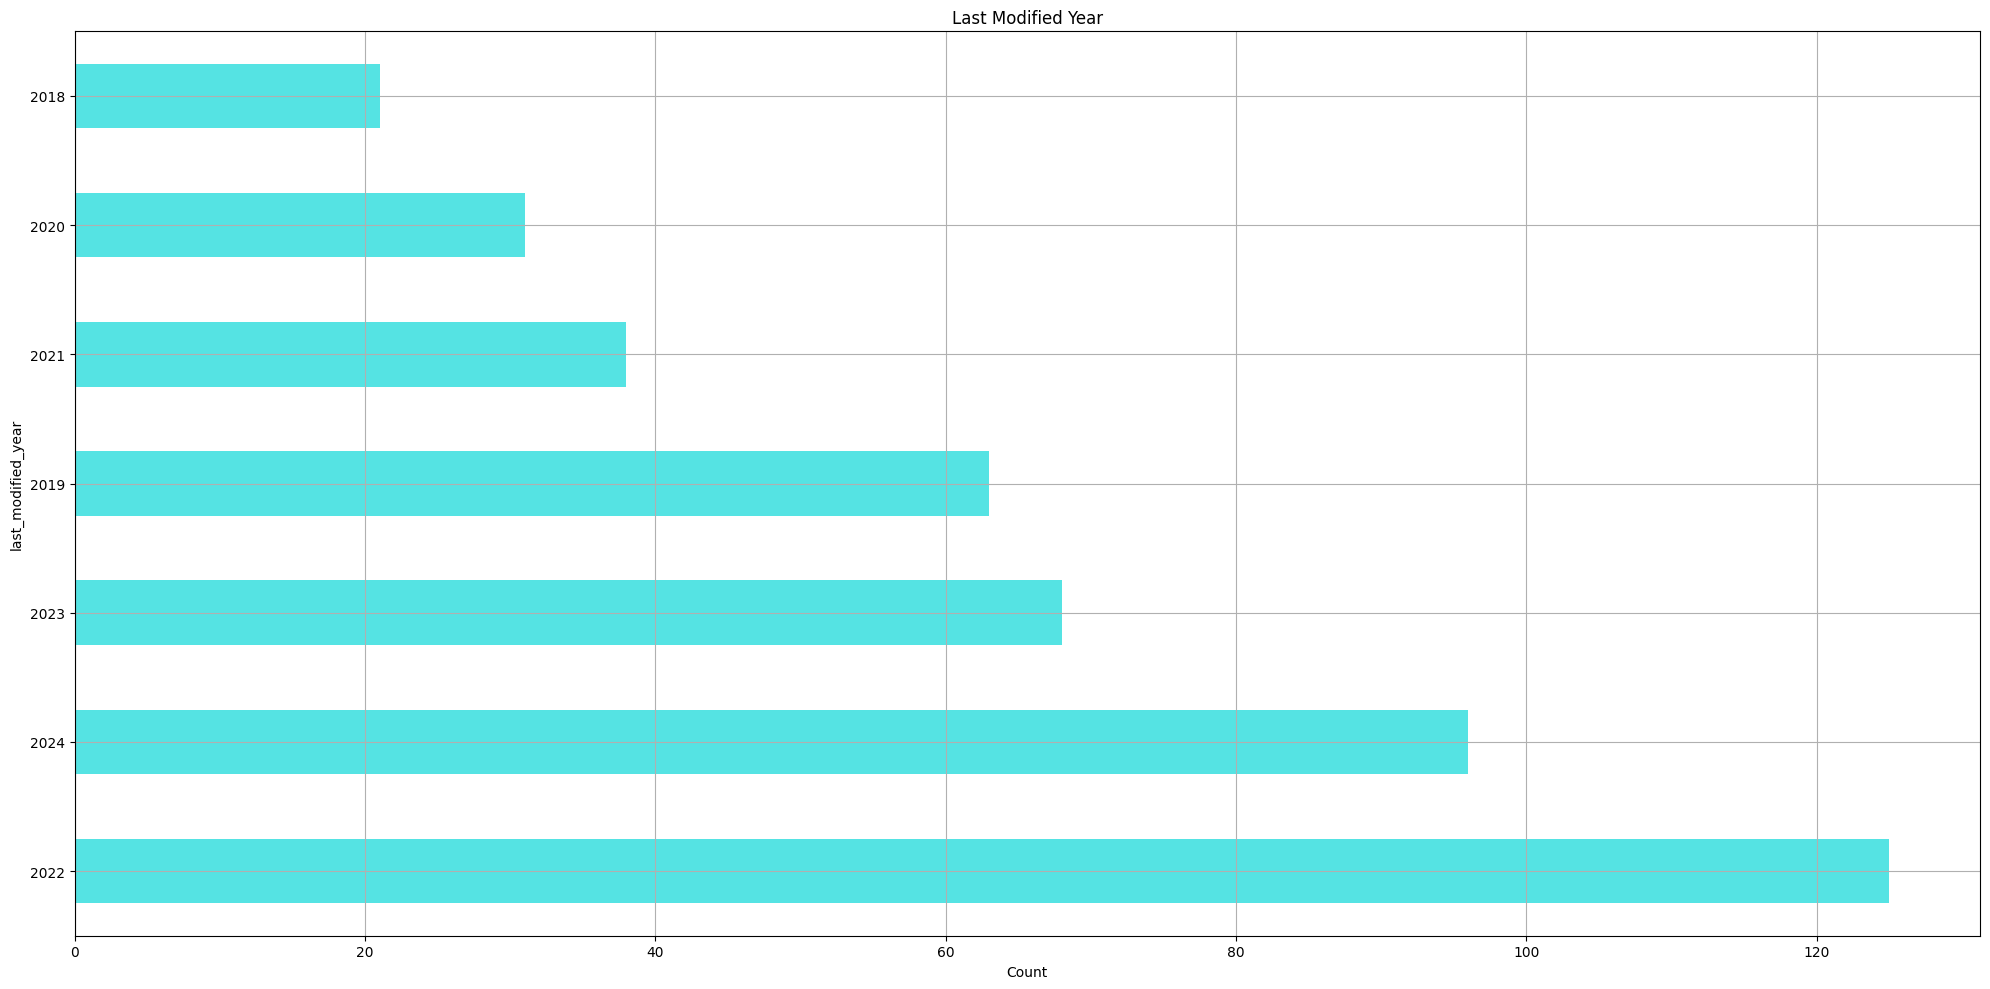

Counter: track_types has 5 entries


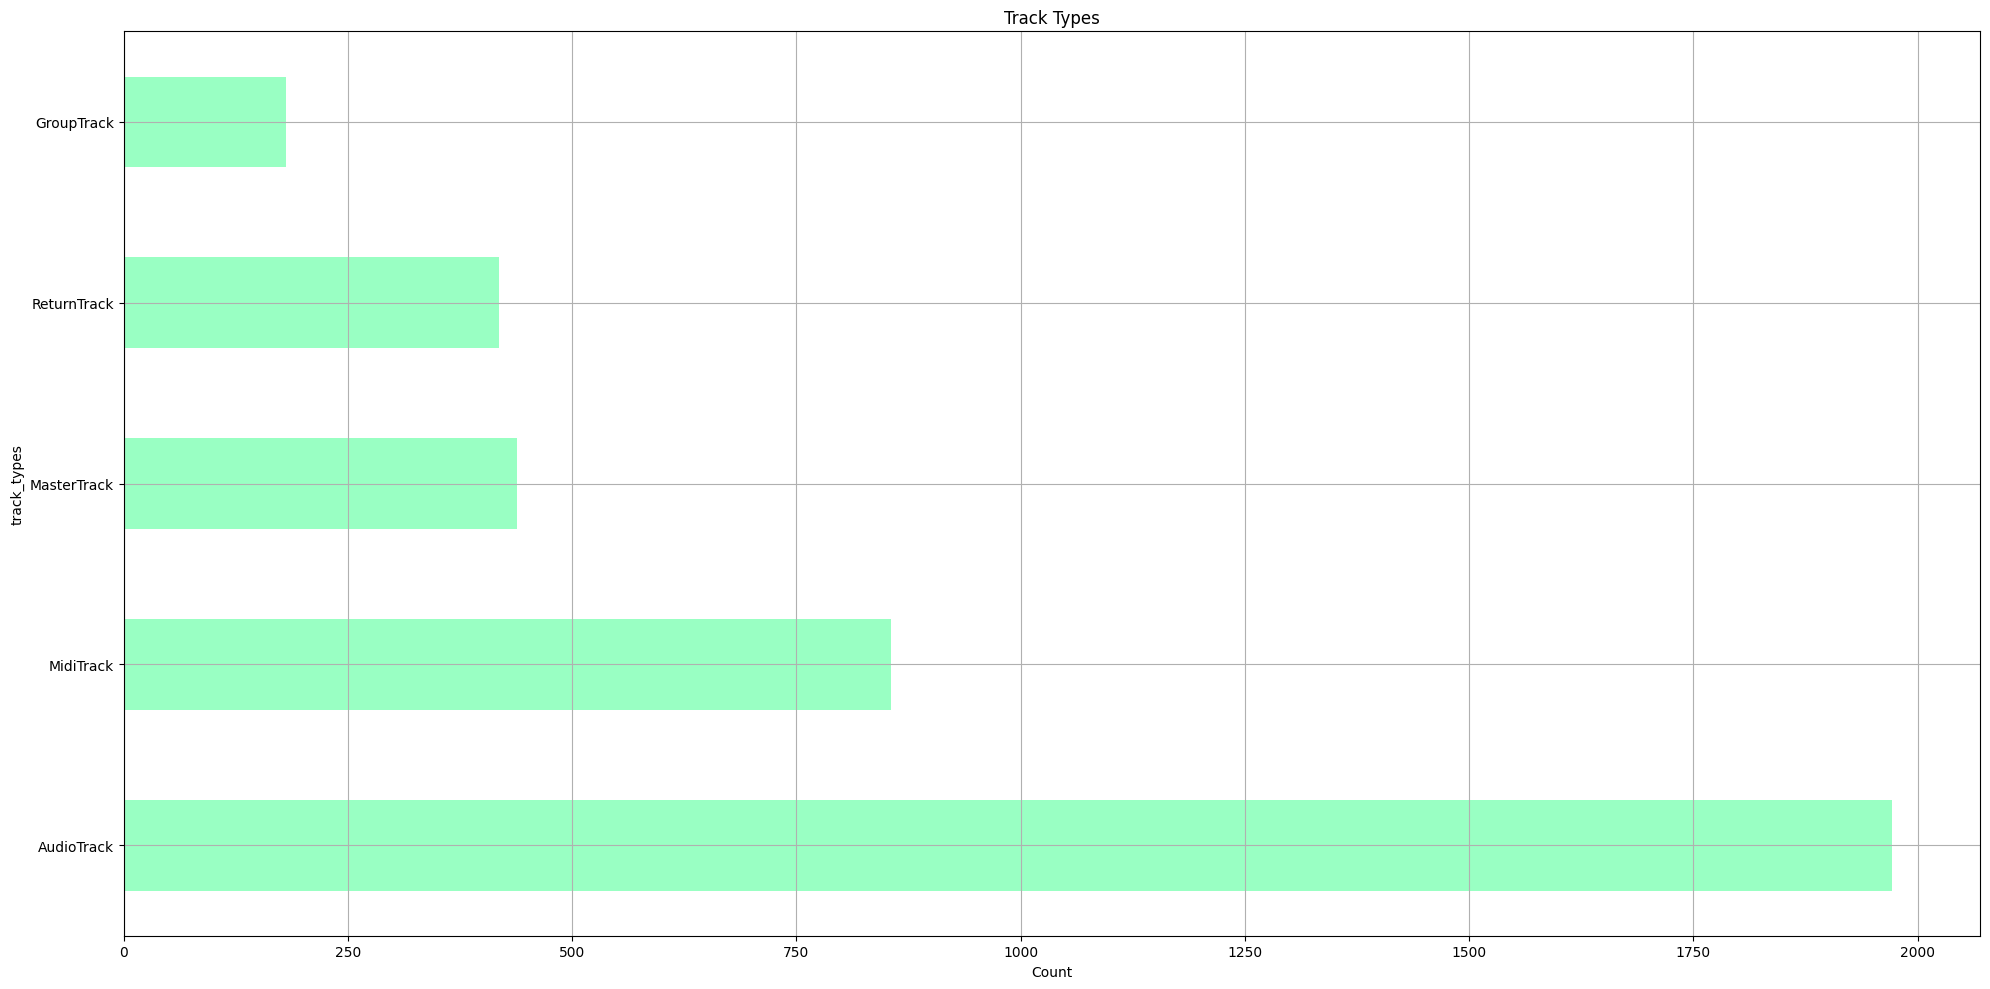

Counter: device_types has 55 entries


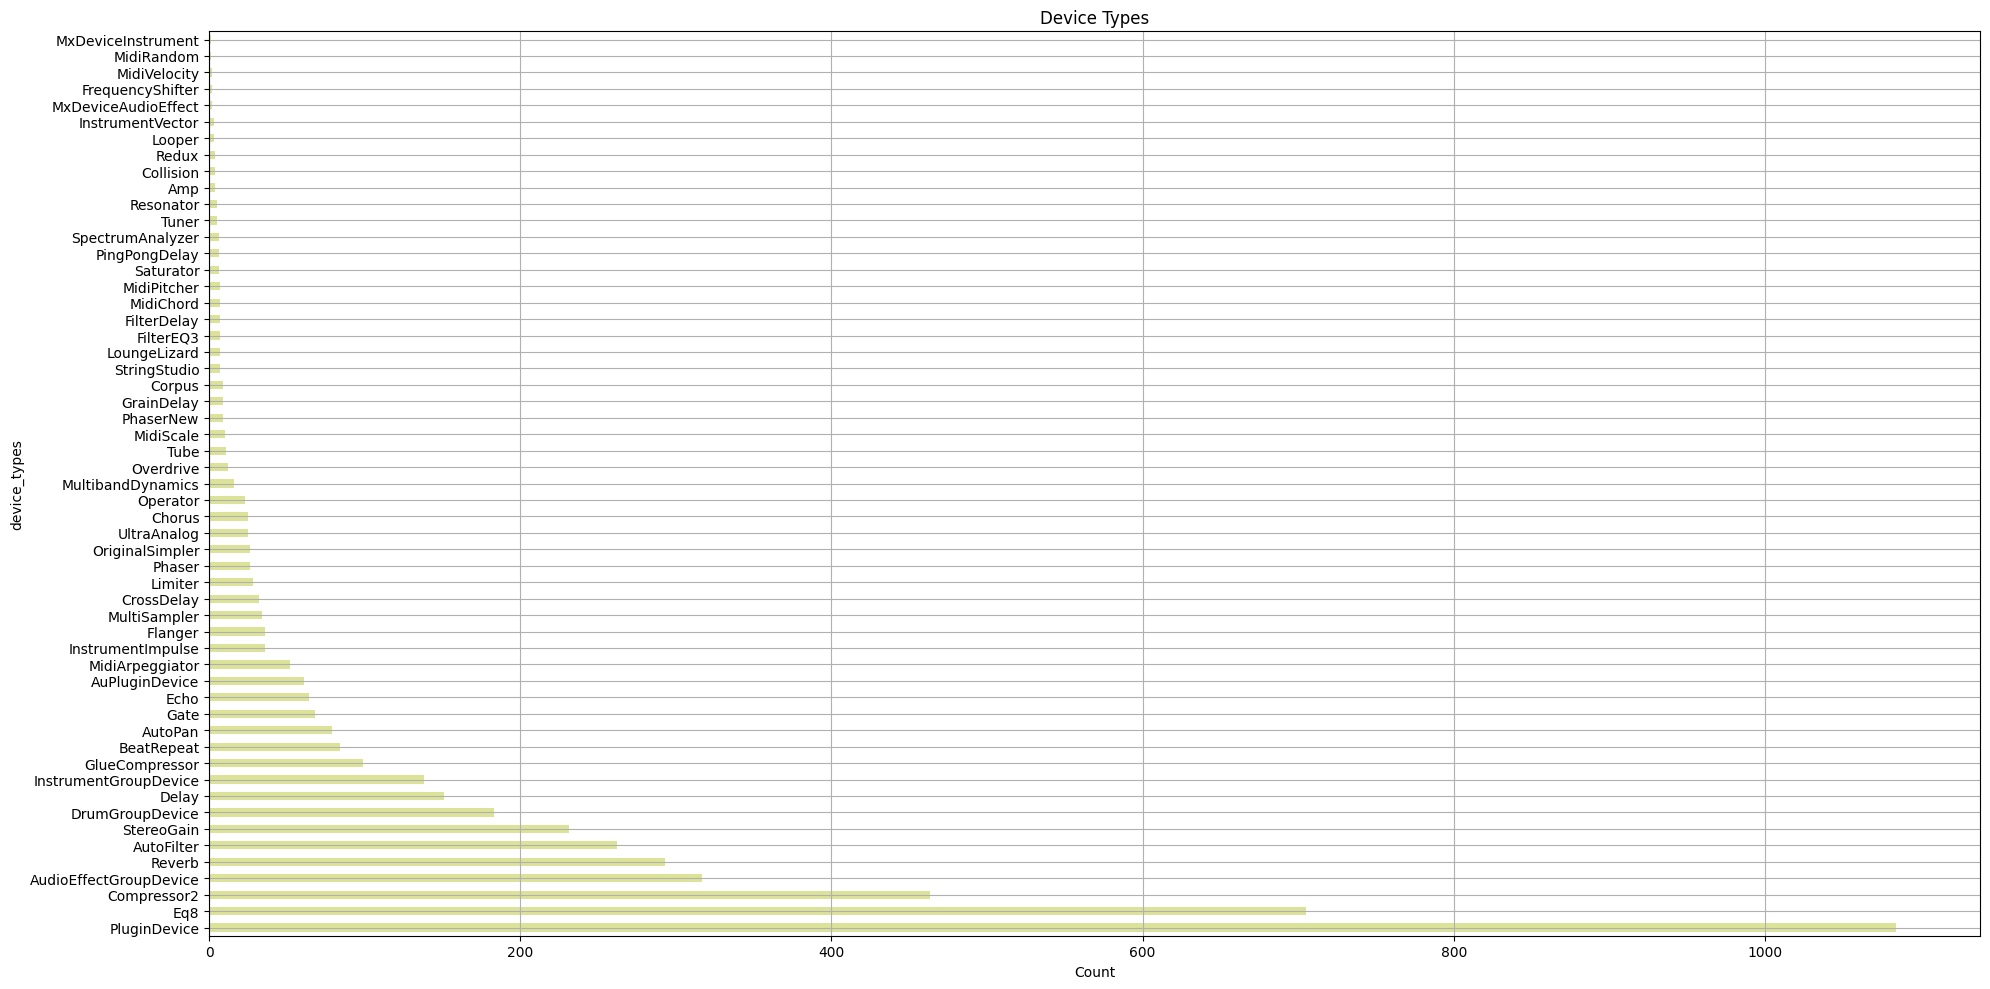

Counter: plugins_vst has 20 entries


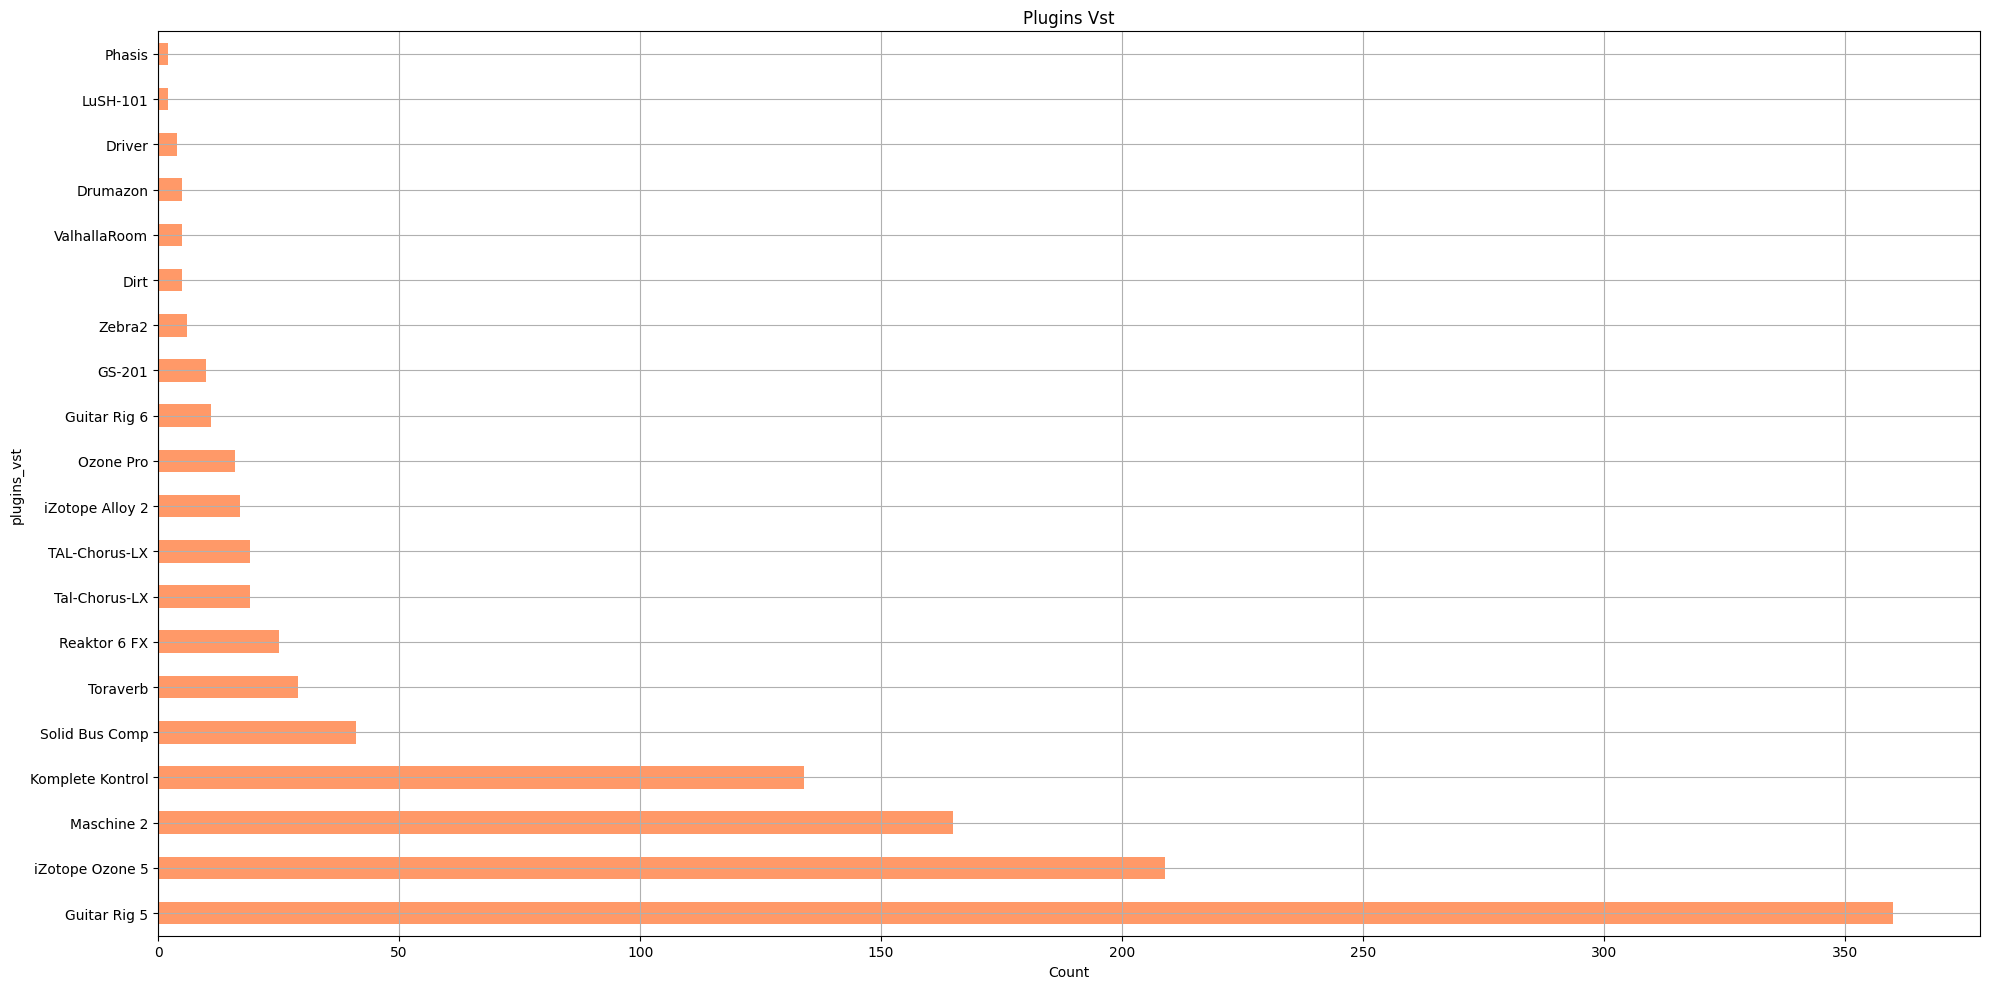

Counter: plugins_au has 3 entries


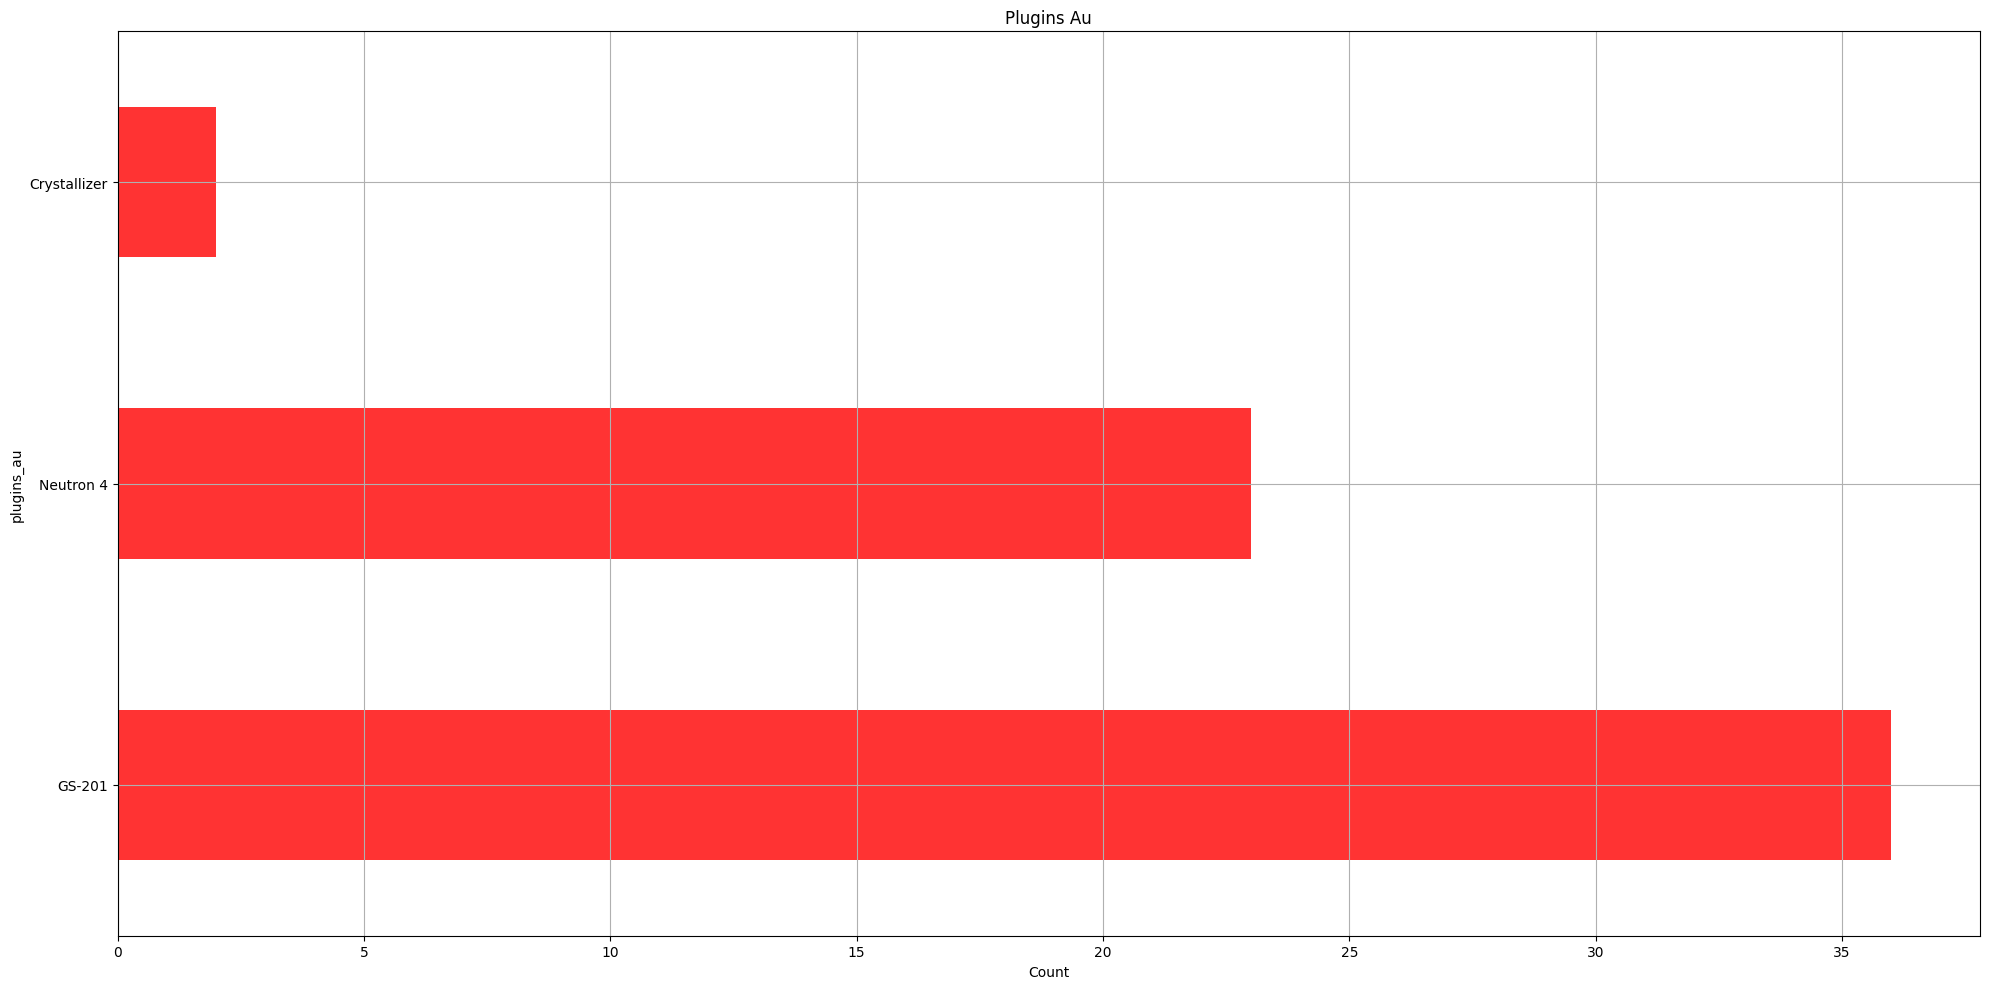

In [10]:
def plot_counters(
    counters,
    top_n=10,
    figsize=(12, 6),
    grid=True,
    alpha=0.8,
    cmap_name='rainbow',
):
  """Generates bar charts for counters, with extensive customization options."""

  num_counters = len(counters) if counters else 0
  cmap = plt.get_cmap(cmap_name, num_counters)  # Use plt.get_cmap
  bar_colors = [cmap(i) for i in range(num_counters)]

  for i, (name, counter) in enumerate(counters.items()):
    print(f'Counter: {name} has {len(counter)} entries')
    if not counter or all(v == 0 for v in counter.values()):
      print(f"WARNING: Counter '{name}' is empty or all zeros. Skipping plot.")
      continue

    df = pd.DataFrame.from_dict(
        counter, orient='index', columns=['count']
    ).sort_values('count', ascending=False)
    df = df.head(top_n)

    title = name.replace('_', ' ').title()
    if top_n:
      title += f' (Top {top_n})'

    df.plot.barh(
        y='count',
        color=[bar_colors[i]],  # Use list of a single color
        figsize=figsize,
        alpha=alpha,
        grid=grid,
        title=title,
        xlabel='Count',
        ylabel=name,
        legend=False,
    )
    plt.tight_layout()
    plt.show()


plot_counters(project_counters, top_n=None, figsize=(20, 10))


## Query 

In [11]:
#@title query helpers

def query_projects_by_plugin(
    project_info: Dict[str, Any], plugin_type: str, preset_name: str, verbose: bool = True
) -> List[str]:
  """Finds projects that use a specific plugin and preset."""
  assert plugin_type in [
      'PluginDevice',
      'AuPluginDevice',
  ], f'Invalid plugin type: {plugin_type}'
  matching_projects = [
      f"{fname}-{track['index']}"
      for fname, v in project_info.items()
      for track in v['tracks']
      for dev in track['devices']
      if dev['type'] == plugin_type and dev['preset'] == preset_name
  ]
  if verbose:
    print(
        f'Projects matching {plugin_type}:'
        f' {preset_name}\n{sorted(matching_projects)}'
    )
  return matching_projects



def query_projects_with_plugin_type(
    project_info: Dict[str, Any], plugin_type: str
) -> List[str]:
  """Finds projects that contain a specific plugin type."""

  assert plugin_type in [
      'PluginDevice',
      'AuPluginDevice',
  ], f'Invalid plugin type: {plugin_type}'

  projects_with_type = [
      fname
      for fname, project in project_info.items()
      if any(
          dev['type'] == plugin_type
          for track in project['tracks']
          for dev in track['devices']
      )
  ]
  print(f"Projects containing '{plugin_type}':\n{sorted(projects_with_type)}")
  return projects_with_type


au_projects = query_projects_with_plugin_type(project_info, 'AuPluginDevice')
query_projects = query_projects_by_plugin(
    project_info, 'PluginDevice', 'Neutron 3'
)


Projects containing 'AuPluginDevice':
['1', '2', '3', '4', '461', '5', 'Blazed Electric Guitar recorded', 'Dance Beat [Loops]', "Dowm Chill 'vErB up", 'Downtime Chill Vibe', 'Green the color', 'Maggots Chill', 'SpokoACIDsampler [song] [unmxd]', 'b itch gowsays [Loops]', 'chill guitar beats lekato', 'dimension live remix 2', 'hazzy chill', 'high vox loops', 'jarryork', 'jarryork 23', 'loaunge chill j a10 gsi', 'lofi accoustic psych', 'psych guiTarr beat', 'something', 'surff classicaL sh', 'trippy vox loops', 'watching fish']
Projects matching PluginDevice: Neutron 3
[]


In [12]:
version = '12'
print(f'Projects from Ableton Version: {version}')
project_df.loc[project_df['ableton_version'] == version].sort_values('path')

Projects from Ableton Version: 12


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,
chill guitar beats lekato,./_lekato demos a12/chill guitar beats lekato ...,12.0_12120,6.22,2024-12-01 16:24:52,2024-12-01 16:24:52,30,12,2024,2024,"AudioTrack, GroupTrack, MidiTrack","Eq8, GlueCompressor, AuPluginDevice, AutoFilter",NaN,Neutron 4
summa time,./_lekato demos a12/summa time Project/summa t...,12.0_12049,0.10,2024-11-30 19:19:49,2024-05-25 16:45:00,13,12,2024,2024,"AudioTrack, GroupTrack, ReturnTrack","Eq8, Compressor2, PhaserNew, Reverb, Delay",NaN,NaN
unsorted loops,./_lekato demos a12/unsorted loops Project/uns...,12.0_12120,0.13,2024-12-01 01:21:41,2024-11-03 22:21:58,7,12,2024,2024,"AudioTrack, MidiTrack",StereoGain,NaN,NaN


In [13]:
# Prefer vst for windows and mac
ALLOW_AUS = ['GS-201', 'GS-201, Crystallizer'] # Used in Dimensions
print(f'Projects with banned AudioUnits:')
project_df.loc[project_df['plugins_au'].notna()].loc[~project_df['plugins_au'].isin(ALLOW_AUS)]

Projects with banned AudioUnits:


,path,ableton_version_full,file_size_mb,created,modified,num_tracks,ableton_version,creation_year,last_modified_year,track_types,device_types,plugins_vst,plugins_au
name,,,,,,,,,,,,,
chill guitar beats lekato,./_lekato demos a12/chill guitar beats lekato ...,12.0_12120,6.22,2024-12-01 16:24:52,2024-12-01 16:24:52,30,12,2024,2024,"AudioTrack, GroupTrack, MidiTrack","Eq8, GlueCompressor, AuPluginDevice, AutoFilter",NaN,Neutron 4


In [8]:
rm_vsts = pd.Series(project_counters['plugins_vst']).sort_values().head(30).to_dict()
for name, count in rm_vsts.items():
    print(f"\n{name} in {count} Projects")
    result = query_projects_by_plugin(project_info, plugin_type="PluginDevice", preset_name=name)



Phasis in 2 Projects
Projects matching PluginDevice: Phasis
['drone acoustic hypnot +-3', 'drone acoustic hypnot-3']

LuSH-101 in 2 Projects
Projects matching PluginDevice: LuSH-101
['broken fluit fly-3', 'kyle Jake funk [house][loops]-3']

Driver in 4 Projects
Projects matching PluginDevice: Driver
['chill guitar track-1', 'dubsteppy-1', 'jam-28', 'motoroik psych jam-4']

Drumazon in 5 Projects
Projects matching PluginDevice: Drumazon
['Fat synth beat [loops][cz100] [oranic]-6', 'REGAE DUB-2', 'dark house start wip-5', 'kyle Jake funk [house][loops]-5', 'wip HISUA [loops]-4']

ValhallaRoom in 5 Projects
Projects matching PluginDevice: ValhallaRoom
['4-20', '4-22', '460 Class EP-1', '461-7', 'SpokoACIDsampler [song] [unmxd]-8']

Dirt in 5 Projects
Projects matching PluginDevice: Dirt
['autotune sad minor guitar-3', 'chill guitar track-1', 'slow dark garage jaaam-3', 'soul hiphoppy guitar jam 2-5', 'soul hiphoppy guitar trackk 2-4']

Zebra2 in 6 Projects
Projects matching PluginDevice:

In [9]:
project_counters['plugins_vst']

{'iZotope Alloy 2': 17,
 'Zebra2': 6,
 'Komplete Kontrol': 134,
 'Maschine 2': 165,
 'Solid Bus Comp': 41,
 'iZotope Ozone 5': 209,
 'Guitar Rig 5': 360,
 'Reaktor 6 FX': 25,
 'Dirt': 5,
 'GS-201': 10,
 'Phasis': 2,
 'Ozone Pro': 16,
 'Toraverb': 29,
 'Driver': 4,
 'TAL-Chorus-LX': 19,
 'Tal-Chorus-LX': 19,
 'ValhallaRoom': 5,
 'Drumazon': 5,
 'LuSH-101': 2,
 'Guitar Rig 6': 11}

In [17]:
for preset in ['Ozone Pro']:
    result = query_projects_by_plugin(project_info, plugin_type="PluginDevice", preset_name=preset, verbose=False)
    print(f'\n{80*'*'}\n{preset}')
    for r in result:
        pr = ''.join(r.split('-')[:-1])
        row = project_df.loc[project_df.index == pr]
        display(row[['num_tracks',  'ableton_version_full', 'plugins_vst', 'plugins_au']].T)
    # display(result)




********************************************************************************
Ozone Pro


name,trum kahled 10
num_tracks,14
ableton_version_full,10.0_377
plugins_vst,Ozone Pro
plugins_au,NaN


name,_machine beats
num_tracks,5
ableton_version_full,10.0_377
plugins_vst,"Maschine 2, Solid Bus Comp, Ozone Pro"
plugins_au,NaN


name,jd jazzy wonk bet
num_tracks,5
ableton_version_full,10.0_377
plugins_vst,"Maschine 2, Solid Bus Comp, Ozone Pro"
plugins_au,NaN


name,all mixed vegitables
num_tracks,28
ableton_version_full,10.0_377
plugins_vst,"iZotope Ozone 5, Ozone Pro, Solid Bus Comp"
plugins_au,NaN


...

name,_guitar pop beats_mixed
num_tracks,5
ableton_version_full,11.0_436
plugins_vst,Ozone Pro
plugins_au,NaN


name,lofi accoustic psych
num_tracks,8
ableton_version_full,10.0_377
plugins_vst,"iZotope Alloy 2, TAL-Chorus-LX, Ozone Pro"
plugins_au,GS-201


name,psych guiTarr beat
num_tracks,7
ableton_version_full,10.0_377
plugins_vst,"Maschine 2, Ozone Pro"
plugins_au,GS-201


name,gitin it all bad [beat][witch] [loops] 2
num_tracks,10
ableton_version_full,10.0_377
plugins_vst,"TAL-Chorus-LX, Toraverb, Ozone Pro"
plugins_au,NaN


name,mixdown
num_tracks,13
ableton_version_full,10.0_377
plugins_vst,"Toraverb, Maschine 2, Ozone Pro"
plugins_au,NaN


In [107]:
# TODO: Update checks below once these AUs are cleared, maybe put checks in parser script
# Flag projects with AU
# these dont have a vst or vst3 equivalent and will not work on windows
tracks_au_flagged = []
for au, count in project_counters['plugins_au'].items():
    if au in ALLOW_AUS:
        print(f'Ignoring AU: {au} as it is in allow list (likely doesnt have a vst version)')
        continue
        
    print(f'Finding projects with AU: {au}...')
    result = query_projects_by_plugin(project_info, plugin_type="AuPluginDevice", preset_name=au)
    for proj in result:
        tracks_au_flagged.append(proj)


Ignoring AU: GS-201 as it is in allow list (likely doesnt have a vst version)
Finding projects with AU: Crystallizer...
Projects matching AuPluginDevice: Crystallizer
['3-32', '3-8']
Finding projects with AU: Neutron 4...
Projects matching AuPluginDevice: Neutron 4
['chill guitar beats lekato-10', 'chill guitar beats lekato-11', 'chill guitar beats lekato-12', 'chill guitar beats lekato-13', 'chill guitar beats lekato-15', 'chill guitar beats lekato-16', 'chill guitar beats lekato-17', 'chill guitar beats lekato-18', 'chill guitar beats lekato-19', 'chill guitar beats lekato-20', 'chill guitar beats lekato-21', 'chill guitar beats lekato-22', 'chill guitar beats lekato-23', 'chill guitar beats lekato-24', 'chill guitar beats lekato-25', 'chill guitar beats lekato-26', 'chill guitar beats lekato-3', 'chill guitar beats lekato-4', 'chill guitar beats lekato-5', 'chill guitar beats lekato-6', 'chill guitar beats lekato-7', 'chill guitar beats lekato-8', 'chill guitar beats lekato-9']


In [15]:
#@title Some checks

DEPRECATED_PLUGINS = [
  "Ozone 8", "Ozone 6",  'iZotope Ozone 5 Reverb', 'iZotope Ozone 5 Imager',
  'Ozone Pro Imager', 'iZotope Stutter Edit', "iZotope Nectar 2",  "Neutron 3", 
  'AmpliTube 4',  'PunchBox', 'Microtonic', 
  'Syntorus', 'Phoscyon', "RC 48", 'Toraverb2', 
  # TDOO "Ozone Pro"
  ] 
for vst in DEPRECATED_PLUGINS:
  print(f'CHECK\t| {vst} should not be an any projects', end='')
  assert 0 == len(query_projects_by_plugin(project_info, "PluginDevice", vst, verbose=False)), f'Failed on {vst}'
  print('...and is not')

ONLY_A10_AUDIO_UNIT = ['Crystallizer', 'GS-201']
for au in ONLY_A10_AUDIO_UNIT:
  print(f'NOTE\t| {au} is only available as a 32 bit audio unit')


CHECK	| Ozone 8 should not be an any projects...and is not
CHECK	| Ozone 6 should not be an any projects...and is not
CHECK	| iZotope Ozone 5 Reverb should not be an any projects...and is not
CHECK	| iZotope Ozone 5 Imager should not be an any projects...and is not
CHECK	| Ozone Pro Imager should not be an any projects...and is not
CHECK	| iZotope Stutter Edit should not be an any projects...and is not
CHECK	| iZotope Nectar 2 should not be an any projects...and is not
CHECK	| Neutron 3 should not be an any projects...and is not
CHECK	| AmpliTube 4 should not be an any projects...and is not
CHECK	| PunchBox should not be an any projects...and is not
CHECK	| Microtonic should not be an any projects...and is not
CHECK	| Syntorus should not be an any projects...and is not
CHECK	| Phoscyon should not be an any projects...and is not
CHECK	| RC 48 should not be an any projects...and is not
CHECK	| Toraverb2 should not be an any projects...and is not
NOTE	| Crystallizer is only available as a

### Query Interface

In [68]:
#@title Query
plugin_type = "PluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "Reaktor 6 FX" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching PluginDevice: Reaktor 6 FX
['2021 mac13 template-1', '2021 mac13 template-2', 'MORE of a jam-10', 'NEW YTEMPLATE-2', 'a-1', 'a-2', 'aciustic mac feedback-1', 'aciustic mac feedback-2', 'acoustic jam psych-1', 'acoustrunkv2-2', 'acoustrunkv2-3', 'acoustrunkv2-4', 'acoustrunkv2-5', 'acoustrunkvo-1', 'acoustrunkvo-2', 'autotune sad minor guitar-3', 'bnchmark-1', 'bnchmark-2', 'current template-2', 'death flutes-6', 'garage rock template-3', 'guitar live-1', 'guitar vox loops downmixed-1', 'guitar vox loops downmixed-2', 'guitar vox loops-1', 'guitar vox loops-2', 'hipohopy-1', 'hipohopy-2', 'loose acousitc distorted vox loop jam-1', 'makings of a jam-2', 'new roume jaamz-1', 'psychccy acoust trip loops-3', 'sad verse psych-1', 'sad verse psych-2', 'single trackpyshch new roume accoustic blah-1', 'slow dark garage jaaam-3', 'soul sample-3', 'template_2020 2-1', 'template_2020 2-2', 'template_2020-1', 'template_2020-2', 'traoppy-6']
Projects matching preset: Reaktor 6 FX

